# Downstream Evaluation: RankMe Evolution → Multilingual Performance

**Research question:** *Does the shape of the RankMe trajectory during pre-training predict downstream multilingual performance? Specifically: does the point where compression begins (onset) and how long it lasts (duration) correlate with accuracy on m-MMLU and XCOPA?*

**Models:** FuxiTranyu-8B · Apertus-8B-2509  
**Benchmarks:** m-MMLU (5-shot, 8 languages) · XCOPA (0-shot, 5 languages)

### What this notebook does
1. **Phase identification** — detects two training phases from the RankMe curve: an *entropy-seeking* phase (RankMe ↑, the model builds richer representations) and a *compression-seeking* phase (RankMe ↓, the model specializes and compresses). For each phase, **onset** is the token count (in billions) where the phase begins, and **duration** is how many tokens it lasts. Works with `fuxi.csv` alone.
2. **Grokking detection** — finds the first checkpoint where accuracy rises more than 15 percentage points above random-chance and stays there for at least 2 consecutive checkpoints. This marks the point where the model transitions from near-random guessing to genuinely solving the task. Requires downstream eval results.
3. **Correlation analysis** — Spearman + Pearson tests: *does an earlier or longer compression phase predict earlier or higher accuracy?* Computed separately per task (m-MMLU / XCOPA), never pooled across tasks.
4. **Plots** — RankMe trajectories, phase overlays (shaded regions drawn on the RankMe curve that visually mark where each phase occurs), dual-axis accuracy curves, and a correlation scatter per task.

> **Note:** Cells that require downstream evaluation results degrade gracefully if `results/eval/` is empty. Run `evaluate.py` (or `submit_eval.sh`) first, then rerun this notebook.

In [1]:
import warnings

import pandas as pd

from utils import (
    load_config,
    load_rankme_data, load_eval_data,
    compute_phases, compute_grokking, compute_correlations_table,
    plot_rankme_phases, plot_overlay, plot_correlation_scatter,
)

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


## Configuration

> 🚨 **Set `MODEL` before running.** Change the variable in the next cell to `"fuxi"` or `"apertus"`. Do not run all cells without doing this — the CSV path, last layer, and model label all derive from that single variable.

`load_config()` automatically derives everything else — CSV paths, which layer to use for phase analysis, grokking detection parameters, and benchmark metadata (languages, random-chance baselines) loaded from `configs/benchmarks.yaml`.

In [2]:
MODEL = "fuxi"   # ← "fuxi" or "apertus"

cfg = load_config(MODEL)
RANKME_CSV          = cfg["rankme_csv"]
MERGED_CSV          = cfg["merged_csv"]
LAYER               = cfg["layer"]
AGGREGATION         = cfg["aggregation"]
MODEL_LABEL         = cfg["model_label"]
GROKKING_THRESHOLD  = cfg["grokking_threshold"]
GROKKING_MIN_CONSEC = cfg["grokking_min_consec"]
RANDOM_CHANCE       = cfg["random_chance"]
TASK_LANGUAGES      = cfg["task_languages"]
PLOTS_DIR           = cfg["plots_dir"]

print(f"Model: {MODEL_LABEL}  |  Layer: {LAYER}  |  Aggregation: {AGGREGATION}")

Model: FuxiTranyu-8B  |  Layer: layer_29  |  Aggregation: last


## Data

Two separate sources are loaded:

- **`fuxi.csv` / `apertus.csv`** — RankMe geometry metrics produced by `geometry_analysis.py` for all model checkpoints, all languages, and all layers. Used for phase identification and phase plots. The working slice (`layer_29`, `agg=last`) gives one RankMe value per (checkpoint, language) pair across the full training run.

- **`fuxi_merged.csv` / `apertus_merged.csv`** — downstream accuracy merged with geometry metrics, produced by `merge_results.py` after running evaluation on the cluster. Only contains the checkpoints that have been evaluated. Used for grokking detection, correlation analysis, and overlay plots.

The phase plots use the full geometry data (all checkpoints). The accuracy-based plots use only the evaluated checkpoints.

In [3]:
df_rankme, df_layer, checkpoints_all, token_counts, langs_sorted = load_rankme_data(RANKME_CSV, LAYER, AGGREGATION)
df_eval, EVAL_AVAILABLE = load_eval_data(MERGED_CSV)

Loaded RankMe: 44,460 rows — 57 checkpoints, 13 languages
Working slice : layer_29, agg=last → 741 rows
Loaded eval: 285 records — 1 task(s), 57 checkpoint(s)


## Phase Identification

The RankMe curve is split into two phases by locating its global peak:

- **Entropy-seeking** — from the first observed checkpoint to the peak (RankMe ↑). The model is building richer, more diverse representations.
- **Compression-seeking** — from the peak to the end of training (RankMe ↓). The model specialises and compresses its representations.

For each phase, **onset** is the token count where it begins and **duration** is how long it lasts. All token values are in **billions (B)**.

A phase is `NaN` when it cannot be observed in the available data:
- **Entropy NaN** — the peak is at the very first checkpoint we have, meaning the entropy-seeking phase either happened before training began or before the earliest checkpoint recorded. This is the case for FuxiTranyu-8B, where RankMe is highest at 10B tokens and decreases from there.
- **Compression NaN** — RankMe never falls after the peak, so no compression phase is detected.

In [4]:
df_phases = compute_phases(df_layer, checkpoints_all, token_counts)

display_cols = {
    "language":                    "language",
    "peak_tokens":                 "peak (B)",
    "entropy_onset_tokens":        "entropy onset (B)",
    "entropy_duration_tokens":     "entropy duration (B)",
    "compression_onset_tokens":    "compression onset (B)",
    "compression_duration_tokens": "compression duration (B)",
}
print(df_phases[list(display_cols)].rename(columns=display_cols).to_string(index=False))

  language  peak (B)  entropy onset (B)  entropy duration (B)  compression onset (B)  compression duration (B)
    Arabic      10.0                NaN                   NaN                   10.0                     583.0
   Chinese      10.0                NaN                   NaN                   10.0                     583.0
   English      10.0                NaN                   NaN                   10.0                     583.0
    French      10.0                NaN                   NaN                   10.0                     583.0
    German      10.0                NaN                   NaN                   10.0                     583.0
     Hindi      10.0                NaN                   NaN                   10.0                     583.0
Indonesian      10.0                NaN                   NaN                   10.0                     583.0
   Italian      10.0                NaN                   NaN                   10.0                     583.0
 

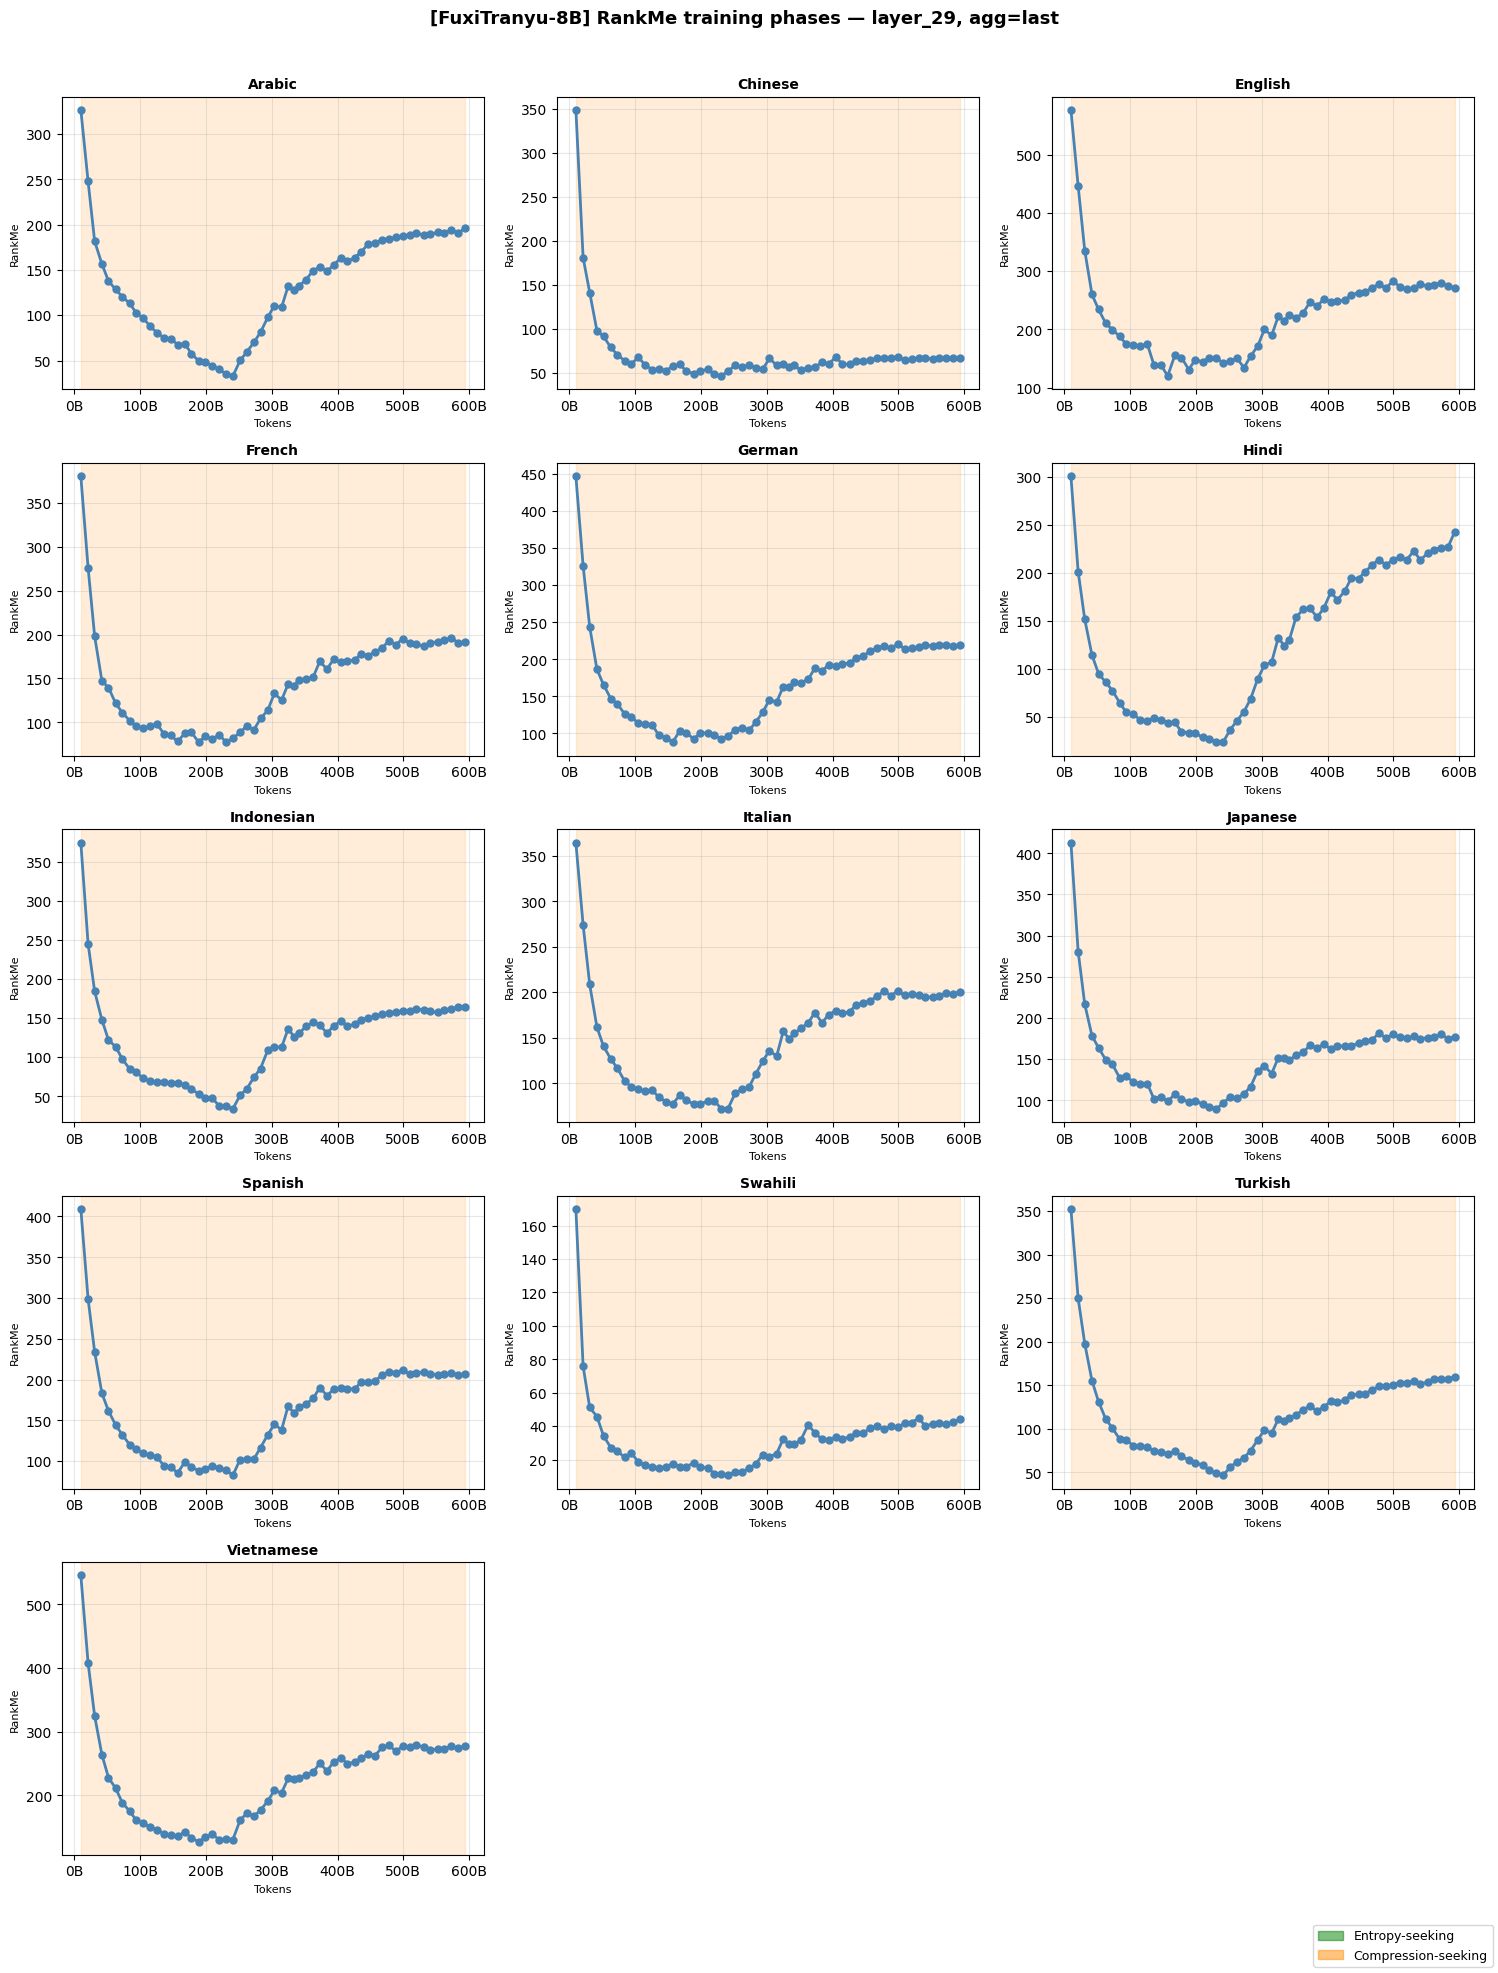

Saved: plots/rankme_phases.png


In [5]:
plot_rankme_phases(df_layer, df_phases, checkpoints_all, token_counts,
                   langs_sorted, MODEL_LABEL, LAYER, AGGREGATION, PLOTS_DIR)

## Grokking Detection

For each (task, language) pair, the table below reports when the model transitions from near-random guessing to genuinely solving the task:

- **grokking_tokens (B)** — token count (in billions) at the first checkpoint where accuracy exceeds random chance by more than 15 percentage points and stays there for at least 2 consecutive checkpoints.
- **peak_tokens (B)** — token count at the checkpoint with the highest observed accuracy.
- **peak_accuracy** — highest accuracy seen across all evaluated checkpoints.
- **random_chance** — baseline accuracy for a random classifier (0.25 for 4-way m-MMLU, 0.50 for 2-way XCOPA).

A `NaN` grokking onset means one of two things: either the model never exceeded the threshold at any evaluated checkpoint (accuracy stays near random chance throughout), or the threshold was crossed only once without the required 2 consecutive checkpoints.

In [6]:
if EVAL_AVAILABLE:
    df_grokking = compute_grokking(df_eval, TASK_LANGUAGES, RANDOM_CHANCE,
                                   threshold=GROKKING_THRESHOLD,
                                   min_consecutive=GROKKING_MIN_CONSEC)
    display_cols = {
        "task":            "task",
        "language":        "language",
        "grokking_tokens": "grokking onset (B)",
        "peak_tokens":     "peak (B)",
        "peak_accuracy":   "peak accuracy",
        "random_chance":   "random chance",
    }
    print(df_grokking[list(display_cols)].rename(columns=display_cols).to_string(index=False))
else:
    df_grokking = pd.DataFrame()
    print("[INFO] No eval data — run submit_eval.sh + merge_results.py first.")

 task   language  grokking onset (B)  peak (B)  peak accuracy  random chance
xcopa    Chinese               325.0     426.0          0.664            0.5
xcopa    Italian               241.0     520.0          0.718            0.5
xcopa Vietnamese               126.0     436.0          0.736            0.5
xcopa    Turkish                 NaN     593.0          0.644            0.5
xcopa Indonesian               241.0     468.0          0.704            0.5


## Correlation Analysis

Tests whether the shape of the RankMe compression phase predicts downstream performance. Two predictors are tested against two outcomes, separately per task:

- **Compression onset (B)** — how early (in billions of tokens) the compression phase begins.
- **Compression duration (B)** — how long the compression phase lasts.

Outcomes:

- **Grokking onset (B)** — when the model first crosses the accuracy threshold (from the grokking table above).
- **Peak accuracy** — the highest accuracy observed across all evaluated checkpoints.

Both Spearman (rank-based) and Pearson (linear) correlations are reported. **n_languages** is the number of languages with non-NaN values for both the predictor and the outcome. `NaN` correlations mean there were fewer than 2 valid data points to compute the correlation.

In [7]:
if EVAL_AVAILABLE and not df_grokking.empty:
    df_correlations = compute_correlations_table(df_grokking, df_phases)
    print(df_correlations.to_string(index=False))
else:
    df_correlations = pd.DataFrame()
    print("[INFO] Skipping correlation analysis — no eval data available.")

 task            predictor (x)        outcome (y)  n_languages  spearman_r  spearman_p  pearson_r  pearson_p
xcopa    Compression onset (B) Grokking onset (B)            4         NaN         NaN        NaN        NaN
xcopa    Compression onset (B)      Peak accuracy            5         NaN         NaN        NaN        NaN
xcopa Compression duration (B) Grokking onset (B)            4         NaN         NaN        NaN        NaN
xcopa Compression duration (B)      Peak accuracy            5         NaN         NaN        NaN        NaN


The scatter plot below visualises compression onset vs peak accuracy (one panel per task) with labeled points per language and a linear regression line.

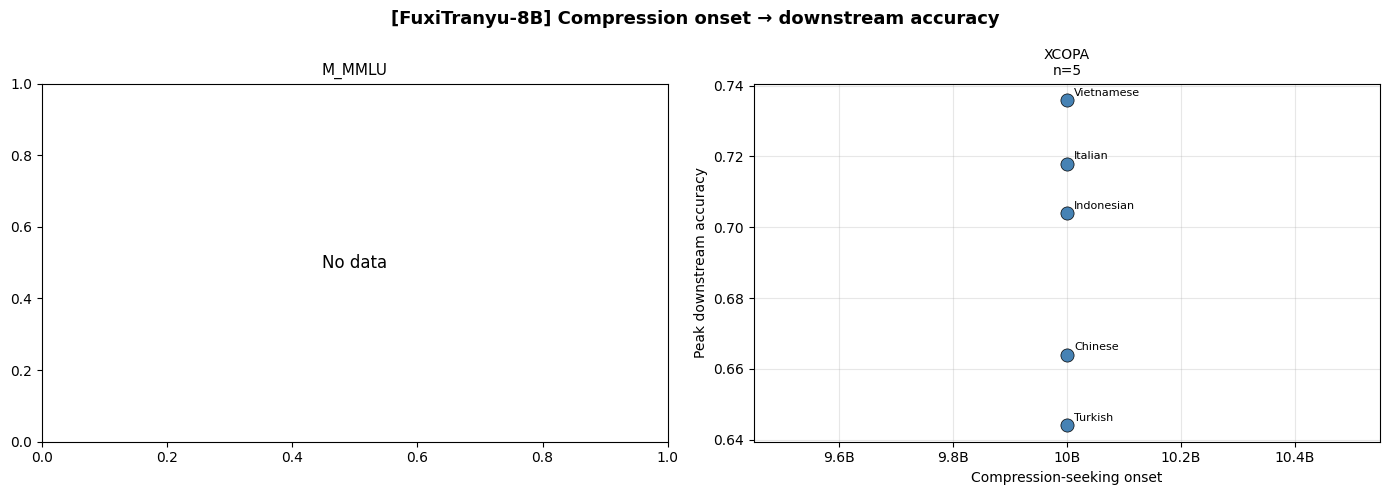

Saved: plots/correlation_scatter.png


In [8]:
if EVAL_AVAILABLE and not df_correlations.empty:
    plot_correlation_scatter(df_grokking, df_phases, MODEL_LABEL, PLOTS_DIR)
else:
    print("[INFO] Skipping correlation scatter — no eval data available.")

## Overlay Plots

One plot per task (m-MMLU, XCOPA), with one panel per language that appears in both the RankMe data and the evaluation results. Each panel shows two y-axes:

- **Left axis (blue)** — RankMe trajectory across all checkpoints, showing the full geometry evolution during pre-training.
- **Right axis (red, dashed)** — downstream accuracy at the evaluated checkpoints only. The axis always spans 0 to 1.

The shaded regions mark the two training phases (green = entropy-seeking, orange = compression-seeking). The black dashed horizontal line marks the random-chance baseline (0.25 for m-MMLU, 0.50 for XCOPA). A vertical purple dashed line marks the grokking onset for that language — it is absent when grokking was not detected (accuracy never exceeded the threshold for 2 consecutive checkpoints).

These plots let you visually inspect whether accuracy rises during or after the compression phase, and whether grokking coincides with any particular point in the RankMe trajectory.

[INFO] No overlapping languages for m_mmlu


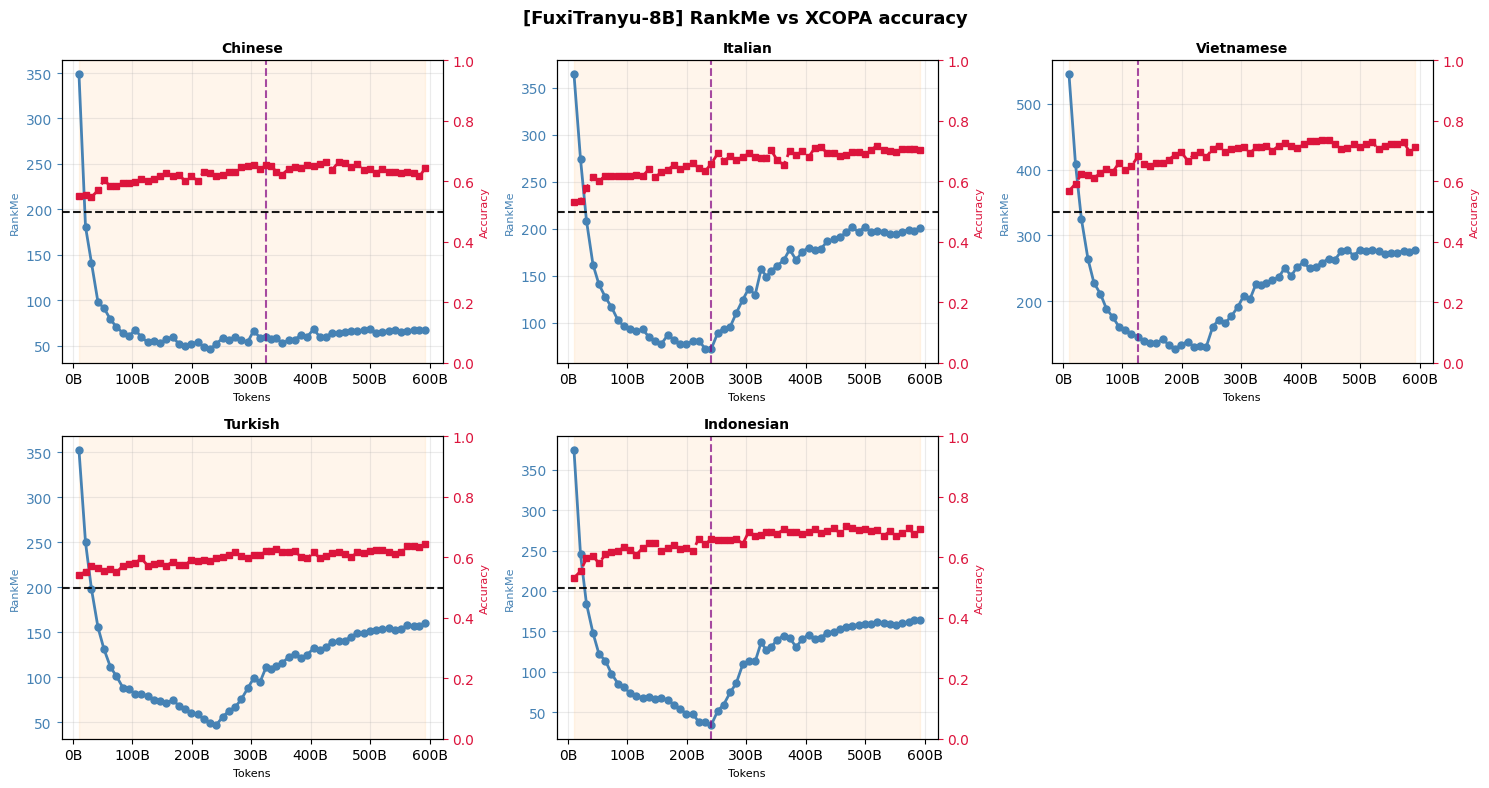

Saved: plots/overlay_xcopa.png


In [9]:
if EVAL_AVAILABLE:
    plot_overlay(df_eval, df_layer, df_phases, df_grokking, TASK_LANGUAGES, RANDOM_CHANCE,
                 checkpoints_all, token_counts, langs_sorted, MODEL_LABEL, PLOTS_DIR)
else:
    print("[INFO] Skipping overlay plots — run evaluate.py first.")

## Summary

### What runs with `fuxi.csv` alone (no eval needed)
- **Phase identification** — entropy-seeking / compression-seeking phases per language, with onset and duration table
- **Phase plot** — RankMe trajectories with phase regions shaded

### What requires downstream evaluation results (`fuxi_merged.csv`)
- **Grokking detection** — table of when each language first exceeds random chance
- **Correlation analysis** — Spearman / Pearson: compression onset and duration → grokking onset and peak accuracy
- **Correlation scatter** — compression onset vs peak accuracy, one panel per task
- **Overlay plots** — RankMe + accuracy dual-axis per language, with phase shading and grokking marker

### Workflow
```bash
# 1 — Submit one cluster job per checkpoint (see README)
for ckpt in 10B 115B ...; do
    ./downstream_evaluation/submit_eval.sh $ckpt fuxi
done

# 2 — After all jobs complete, merge once manually (see README)

# 3 — Rerun this notebook — all cells activate automatically
```